# Exploratory Data Analysis of AdoptAI System Metrics

This dataset contains system-performance measurements collected from several machines. The data has already been merged and cleaned.

The objective is to understand its structure, quality, distributions, outliers, correlations, reliability, machine differences, and changes over time before preprocessing and machine learning.

This notebook only reads and analyzes the data. It does not modify the original CSV file.

## 1. Import Libraries

Import the simple tools needed for data analysis and charts.

In [1]:
import pandas as pd              # Work with tables
import numpy as np               # Work with numerical values
import matplotlib.pyplot as plt # Create charts
from pathlib import Path         # Build file paths

## 2. Define the Dataset Path

Find the project folder safely, whether the notebook starts from the project root or the `notebooks` folder.

In [2]:
current_folder = Path.cwd()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder
data_path = project_root / "data" / "processed" / "cleaned_metrics.csv"
print("Dataset path:", data_path)

Dataset path: /Users/fatimazahranamaoui/Desktop/ADOPTAI/AdoptAI_V1/data/processed/cleaned_metrics.csv


## 3. Load the Dataset

Check that the cleaned CSV exists, then load it without changing the file.

In [3]:
if data_path.exists():
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully.")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
else:
    df = pd.DataFrame()
    print("Dataset not found. Check the path shown above.")

Dataset loaded successfully.
Rows: 31059
Columns: 39


## 4. Preview the Dataset

These previews help verify the content at the beginning, end, and across random positions.

In [53]:
# First five rows
df.head()

,id,run_id,machine_id,timestamp,elapsed_seconds,phase,stress_cpu_target_pct,stress_memory_target_mb,cpu_pct,cpu_per_core_json,...,gpu_per_device_json,battery_pct,battery_plugged,sensor_errors_json,missed_deadline,legacy_id,sample_reliable,status,ended_at_utc,run_complete
0,1,6835f125-a038-4092-beff-5107ae998b39,0890dcc046c079acc4de4202,2026-07-25T14:45:59.803000Z,1.022,monitor,NaN,NaN,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,[],49.0,0,"{""network_latency"": ""TimeoutError: timed out"",...",0,NaN,0,completed,2026-07-25T16:45:58.885Z,1
1,2,6835f125-a038-4092-beff-5107ae998b39,0890dcc046c079acc4de4202,2026-07-25T14:46:00.857000Z,2.076,monitor,NaN,NaN,9.8,"[19.2, 18.6, 15.4, 10.5, 8.5, 3.0, 2.0, 11.1, ...",...,[],49.0,0,"{""temperature"": ""macmon_not_installed (install...",0,NaN,0,completed,2026-07-25T16:45:58.885Z,1
2,3,6835f125-a038-4092-beff-5107ae998b39,0890dcc046c079acc4de4202,2026-07-25T14:46:02.829000Z,4.048,monitor,NaN,NaN,5.4,"[15.6, 12.6, 10.6, 8.5, 1.0, 0.0, 0.0, 3.0, 1....",...,[],49.0,0,"{""temperature"": ""macmon_not_installed (install...",0,NaN,0,completed,2026-07-25T16:45:58.885Z,1
3,4,6835f125-a038-4092-beff-5107ae998b39,0890dcc046c079acc4de4202,2026-07-25T14:46:04.845000Z,6.063,monitor,NaN,NaN,4.6,"[17.0, 11.5, 9.0, 6.0, 0.5, 0.0, 0.0, 1.5, 1.0...",...,[],49.0,0,"{""temperature"": ""macmon_not_installed (install...",0,NaN,0,completed,2026-07-25T16:45:58.885Z,1
4,5,6835f125-a038-4092-beff-5107ae998b39,0890dcc046c079acc4de4202,2026-07-25T14:46:06.853000Z,8.071,monitor,NaN,NaN,7.3,"[20.2, 16.6, 10.1, 14.6, 1.0, 0.5, 0.5, 5.0, 3...",...,[],49.0,0,"{""temperature"": ""macmon_not_installed (install...",0,NaN,0,completed,2026-07-25T16:45:58.885Z,1


#### Line-by-line explanation

1. `# First five rows` — Comment explaining the next instruction.
2. `df.head()` — Shows the first five rows.

In [5]:
# Last five rows
df.tail()

,id,run_id,machine_id,timestamp,elapsed_seconds,phase,stress_cpu_target_pct,stress_memory_target_mb,cpu_pct,cpu_per_core_json,...,gpu_per_device_json,battery_pct,battery_plugged,sensor_errors_json,missed_deadline,legacy_id,sample_reliable,status,ended_at_utc,run_complete
21550,21551,f24e9c1a-f11e-405c-b663-45fa6e25c405,a0f8c86097e55fbfa506d057,2026-07-27T15:28:56.310000Z,7933.348,monitor,NaN,NaN,52.6,"[53.7, 45.0, 56.7, 53.5, 48.8, 48.1, 48.8, 65.4]",...,"[{""name"": ""Intel(R) Iris(R) Plus Graphics 655""...",24.0,0,{},0,NaN,1,running,NaN,0
21551,21552,f24e9c1a-f11e-405c-b663-45fa6e25c405,a0f8c86097e55fbfa506d057,2026-07-27T15:28:58.502000Z,7935.540,monitor,NaN,NaN,45.5,"[39.7, 43.0, 56.0, 41.4, 35.2, 39.1, 46.9, 61.7]",...,"[{""name"": ""Intel(R) Iris(R) Plus Graphics 655""...",24.0,0,{},0,NaN,1,running,NaN,0
21552,21553,f24e9c1a-f11e-405c-b663-45fa6e25c405,a0f8c86097e55fbfa506d057,2026-07-27T15:29:00.259000Z,7937.297,monitor,NaN,NaN,49.0,"[45.0, 38.6, 58.4, 46.5, 44.1, 43.3, 50.4, 65.4]",...,"[{""name"": ""Intel(R) Iris(R) Plus Graphics 655""...",24.0,0,{},0,NaN,1,running,NaN,0
21553,21554,f24e9c1a-f11e-405c-b663-45fa6e25c405,a0f8c86097e55fbfa506d057,2026-07-27T15:29:02.184000Z,7939.222,monitor,NaN,NaN,43.8,"[35.6, 28.5, 50.7, 47.7, 32.8, 35.9, 49.2, 69.5]",...,"[{""name"": ""Intel(R) Iris(R) Plus Graphics 655""...",24.0,0,{},0,NaN,1,running,NaN,0
21554,21555,f24e9c1a-f11e-405c-b663-45fa6e25c405,a0f8c86097e55fbfa506d057,2026-07-27T15:29:04.453000Z,7941.491,monitor,NaN,NaN,42.5,"[41.5, 31.8, 46.7, 53.1, 27.3, 32.8, 43.0, 63.6]",...,"[{""name"": ""Intel(R) Iris(R) Plus Graphics 655""...",24.0,0,{},0,NaN,1,running,NaN,0


#### Line-by-line explanation

1. `# Last five rows` — Comment explaining the next instruction.
2. `df.tail()` — Shows the last five rows.

### Why do we display random rows?

After loading the dataset, we inspect a few **random rows** to better understand the data.

Unlike `head()`, which always shows the first rows, a random sample lets us check whether the data looks consistent throughout the dataset and helps detect unexpected values.

This step **does not modify the dataset**; it is only for visual inspection during EDA.

In [6]:
# Random rows, only when data is available
if len(df) >= 5:
    display(df.sample(5, random_state=42))
else:
    print("Not enough rows for a five-row random sample.")

,id,run_id,machine_id,timestamp,elapsed_seconds,phase,stress_cpu_target_pct,stress_memory_target_mb,cpu_pct,cpu_per_core_json,...,gpu_per_device_json,battery_pct,battery_plugged,sensor_errors_json,missed_deadline,legacy_id,sample_reliable,status,ended_at_utc,run_complete
8645,8646,89cdc34b-e02b-43b4-9284-144276df508a,0890dcc046c079acc4de4202,2026-07-23T17:48:57.783000Z,10090.836,monitor,NaN,NaN,12.0,"[30.3, 26.6, 20.7, 18.1, 12.9, 5.0, 3.5, 3.0, ...",...,[],40.0,0,"{""temperature"": ""macmon_not_installed (install...",0,NaN,0,interrupted,2026-07-23T20:03:12.803Z,0
12353,12354,89cdc34b-e02b-43b4-9284-144276df508a,0890dcc046c079acc4de4202,2026-07-23T20:02:06.870000Z,17506.073,monitor,NaN,NaN,11.1,"[22.3, 21.3, 18.8, 13.5, 6.5, 1.5, 0.0, 19.5, ...",...,[],78.0,1,"{""temperature"": ""macmon_not_installed (install...",0,NaN,0,interrupted,2026-07-23T20:03:12.803Z,0
3261,3262,6835f125-a038-4092-beff-5107ae998b39,0890dcc046c079acc4de4202,2026-07-25T16:34:40.955000Z,6522.067,monitor,NaN,NaN,3.5,"[11.6, 11.5, 7.5, 3.5, 1.0, 0.0, 0.0, 0.0, 0.0...",...,[],28.0,0,"{""temperature"": ""macmon_not_installed (install...",0,NaN,0,completed,2026-07-25T16:45:58.885Z,1
11187,11188,89cdc34b-e02b-43b4-9284-144276df508a,0890dcc046c079acc4de4202,2026-07-23T19:23:14.904000Z,15174.113,monitor,NaN,NaN,8.7,"[24.7, 23.2, 17.1, 15.1, 0.5, 0.5, 0.0, 2.5, 2...",...,[],30.0,1,"{""temperature"": ""macmon_not_installed (install...",0,NaN,0,interrupted,2026-07-23T20:03:12.803Z,0
19142,19143,f24e9c1a-f11e-405c-b663-45fa6e25c405,a0f8c86097e55fbfa506d057,2026-07-27T14:07:18.217000Z,3035.255,monitor,NaN,NaN,68.7,"[66.2, 62.0, 68.8, 74.2, 70.3, 62.5, 66.4, 79.7]",...,"[{""name"": ""Intel(R) Iris(R) Plus Graphics 655""...",57.0,1,{},0,NaN,1,running,NaN,0


### Preview observation

Check whether the rows and column values look consistent with system measurements from different machines.

## 5. Dataset Structure

Inspect the size, names, types, and non-missing counts.

In [73]:
print("Dataframe shape:", df.shape)

Dataframe shape: (31059, 39)


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['id', 'run_id', 'machine_id', 'timestamp', 'elapsed_seconds', 'phase', 'stress_cpu_target_pct', 'stress_memory_target_mb', 'cpu_pct', 'cpu_per_core_json', 'cpu_frequency_mhz', 'ram_pct', 'ram_used_mb', 'ram_available_mb', 'swap_pct', 'swap_used_mb', 'disk_usage_pct', 'disk_free_gb', 'disk_read_mb_s', 'disk_write_mb_s', 'disk_latency_ms', 'net_sent_mb_s', 'net_recv_mb_s', 'network_latency_ms', 'process_count', 'thread_count', 'context_switches_per_s', 'temperature_c', 'gpu_usage_pct', 'gpu_per_device_json', 'battery_pct', 'battery_plugged', 'sensor_errors_json', 'missed_deadline', 'legacy_id', 'sample_reliable', 'status', 'ended_at_utc', 'run_complete']


In [5]:
print("Data types:")
display(df.dtypes.to_frame("data_type"))

Data types:


,data_type
id,int64
run_id,str
machine_id,str
timestamp,str
elapsed_seconds,float64
phase,str
stress_cpu_target_pct,float64
stress_memory_target_mb,float64
cpu_pct,float64
cpu_per_core_json,str


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31059 entries, 0 to 31058
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       31059 non-null  int64  
 1   run_id                   31059 non-null  str    
 2   machine_id               31059 non-null  str    
 3   timestamp                31059 non-null  str    
 4   elapsed_seconds          31059 non-null  float64
 5   phase                    31059 non-null  str    
 6   stress_cpu_target_pct    0 non-null      float64
 7   stress_memory_target_mb  0 non-null      float64
 8   cpu_pct                  31059 non-null  float64
 9   cpu_per_core_json        31059 non-null  str    
 10  cpu_frequency_mhz        31059 non-null  float64
 11  ram_pct                  31059 non-null  float64
 12  ram_used_mb              31059 non-null  float64
 13  ram_available_mb         31059 non-null  float64
 14  swap_pct                 31059 no

### Structure observation

Note which columns are numbers, text, identifiers, or dates. A wrong data type may need correction during preprocessing.

## 6. Convert Timestamp Columns

Timestamps must be datetime values for time analysis. Invalid text becomes `NaT` but is not removed.

### Goal of this cell

Convert timestamp columns to datetime format so Python can perform time-based analysis and safely detect invalid dates.
So we can later:

analyze data over time,
calculate run durations,
sort by timestamp,
create time-series graphs,
identify invalid timestamps

In [7]:
timestamp_columns = ["timestamp", "ended_at_utc", "started_at_utc"]
for column in timestamp_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce", utc=True)
        print(column, "invalid or missing values:", df[column].isna().sum())
    else:
        print(column, "is not available; skipped.")

timestamp invalid or missing values: 0
ended_at_utc invalid or missing values: 5431
started_at_utc is not available; skipped.


## 7. Duplicate Analysis

Verify duplicate rows. This notebook reports duplicates but does not delete them.

In [8]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


In [9]:
if {"run_id", "timestamp"}.issubset(df.columns):
    pair_duplicates = df.duplicated(subset=["run_id", "timestamp"]).sum()
    print("Duplicate run_id and timestamp pairs:", pair_duplicates)
else:
    print("run_id or timestamp is missing; pair check skipped.")

Duplicate run_id and timestamp pairs: 0


### Duplicate observation

Cleaning should have handled duplicates. Any remaining duplicates should be investigated before modeling.

## 8. Missing-Value Analysis

Count missing values and percentages for every column.

In [10]:
missing_table = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100).round(2)
}).sort_values("missing_percentage", ascending=False)
missing_columns = missing_table[missing_table["missing_count"] > 0]
display(missing_columns)

,column,missing_count,missing_percentage
34,legacy_id,31059,100.00
6,stress_cpu_target_pct,31059,100.00
7,stress_memory_target_mb,31059,100.00
27,temperature_c,12726,40.97
28,gpu_usage_pct,12386,39.88
26,context_switches_per_s,7427,23.91
37,ended_at_utc,5431,17.49
23,network_latency_ms,5404,17.40
20,disk_latency_ms,11,0.04
18,disk_read_mb_s,11,0.04


### Goal of this cell

After identifying missing values in each column, we now want to know which columns are **complete**.

A complete column contains **no missing values**, meaning every row has a value.

These columns usually require less preprocessing and are generally more reliable for analysis.

In [11]:
complete_columns = missing_table[missing_table["missing_count"] == 0][["column"]]
print("Columns without missing values:")
display(complete_columns)

Columns without missing values:


,column
29,gpu_per_device_json
31,battery_plugged
32,sensor_errors_json
25,thread_count
24,process_count
33,missed_deadline
35,sample_reliable
36,status
30,battery_pct
0,id


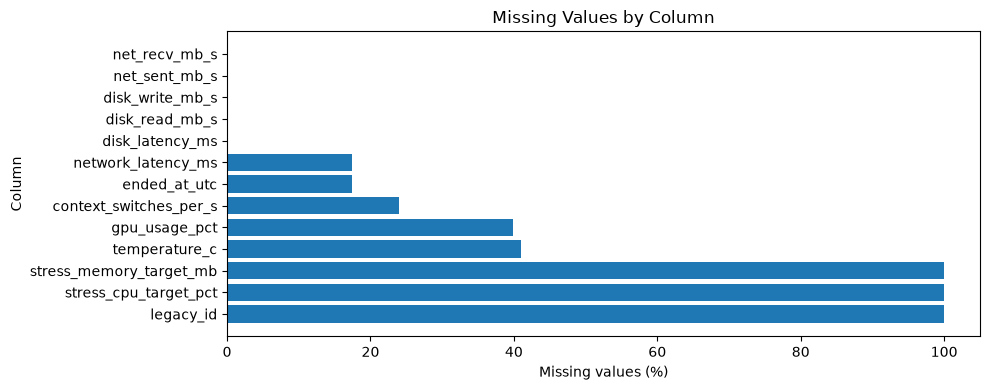

In [12]:
if not missing_columns.empty:
    plt.figure(figsize=(10, max(4, len(missing_columns) * 0.3)))
    plt.barh(missing_columns["column"], missing_columns["missing_percentage"])
    plt.title("Missing Values by Column")
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values were found.")

### Missing-value observation

Look for columns with high missing percentages. Decide later whether missing values mean an unavailable sensor, a collection problem, or a value that needs treatment.

## 9. Descriptive Statistics

Summaries show the center, spread, and range of each variable.

### Goal of this cell

This section generates descriptive statistics for all numerical columns in the dataset.

It helps us understand the distribution of each metric by displaying values such as the minimum, maximum, mean, median, and standard deviation.

This analysis allows us to detect unusual values, understand the range of the data, and prepare for future preprocessing and machine learning.

In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
if numeric_columns:
    display(df[numeric_columns].describe().T)
else:
    print("No numerical columns are available.")

,count,mean,std,min,25%,50%,75%,max
id,31059.0,15530.000000,8966.105342,1.0000,7765.5000,15530.0000,23294.50000,31059.0000
elapsed_seconds,31059.0,5803.469454,4336.256458,0.0960,2297.2615,4960.0610,8091.42350,17570.0520
stress_cpu_target_pct,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stress_memory_target_mb,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu_pct,31059.0,31.840462,28.780807,0.0000,9.1000,17.8000,50.50000,100.0000
cpu_frequency_mhz,31059.0,2431.605171,1067.681144,1101.0000,1101.0000,2803.0000,3504.00000,3504.0000
ram_pct,31059.0,69.150916,15.497176,29.7000,51.7000,75.6000,80.10000,99.1000
ram_used_mb,31059.0,8803.316082,3478.972655,4758.6000,5865.7500,8168.8000,9841.20000,16888.3000
ram_available_mb,31059.0,5266.317145,2629.746349,159.4000,3406.0000,4184.9000,8219.40000,11967.4000
swap_pct,31059.0,24.890489,23.631520,0.0000,2.8000,12.3000,47.70000,70.5000


In [14]:
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
if categorical_columns:
    display(df[categorical_columns].describe(include="all").T)
else:
    print("No categorical columns are available.")

,count,unique,top,freq,mean,min,25%,50%,75%,max
run_id,31059,10,89cdc34b-e02b-43b4-9284-144276df508a,8786,NaN,NaN,NaN,NaN,NaN,NaN
machine_id,31059,3,0890dcc046c079acc4de4202,12386,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,31059,NaN,NaN,NaN,2026-07-26 20:05:44.351710+00:00,2026-07-23 15:00:46.964000+00:00,2026-07-23 19:29:09.967000+00:00,2026-07-27 14:50:14.273000+00:00,2026-07-28 17:53:19.220500+00:00,2026-07-29 13:45:26.708000+00:00
phase,31059,1,monitor,31059,NaN,NaN,NaN,NaN,NaN,NaN
cpu_per_core_json,31059,29718,"[100.0, 100.0, 100.0, 100.0]",1291,NaN,NaN,NaN,NaN,NaN,NaN
gpu_per_device_json,31059,558,[],12386,NaN,NaN,NaN,NaN,NaN,NaN
sensor_errors_json,31059,8,{},13805,NaN,NaN,NaN,NaN,NaN,NaN
status,31059,3,interrupted,22028,NaN,NaN,NaN,NaN,NaN,NaN
ended_at_utc,25628,NaN,NaN,NaN,2026-07-26 10:41:05.455515+00:00,2026-07-23 20:03:12.803000+00:00,2026-07-23 20:03:12.803000+00:00,2026-07-27 15:32:27.219000+00:00,2026-07-28 13:10:18.015000+00:00,2026-07-28 21:17:03.789000+00:00


In [15]:
display(df.nunique(dropna=False).sort_values(ascending=False).to_frame("unique_values"))

,unique_values
id,31059
timestamp,31059
elapsed_seconds,30997
cpu_per_core_json,29718
ram_used_mb,23256
ram_available_mb,22388
context_switches_per_s,21789
network_latency_ms,21204
disk_write_mb_s,11506
disk_read_mb_s,11193


### Statistics observation

Compare means and medians. A large difference can suggest a skewed distribution or unusual values.

## 10. Identify Metric Groups

Group available columns into understandable metric families.

In [16]:
metric_candidates = {
    "CPU": ["cpu_pct", "cpu_frequency_mhz", "cpu_freq_mhz", "load_avg_1m", "load_avg_5m", "load_avg_15m"],
    "Memory": ["ram_pct", "ram_used_mb", "ram_available_mb", "swap_pct", "swap_used_mb"],
    "Disk": ["disk_usage_pct", "disk_read_mb_s", "disk_write_mb_s", "disk_latency_ms"],
    "Network": ["net_sent_mb_s", "net_recv_mb_s", "network_latency_ms"],
    "Hardware": ["temperature_c", "gpu_usage_pct", "battery_pct"],
    "System": ["process_count", "thread_count", "context_switches_per_s"],
    "Quality": ["sample_reliable", "run_complete", "missed_deadline"]
}
metric_groups = {}
for group_name, candidates in metric_candidates.items():
    metric_groups[group_name] = [column for column in candidates if column in df.columns]
    print(group_name + ":", metric_groups[group_name])

CPU: ['cpu_pct', 'cpu_frequency_mhz']
Memory: ['ram_pct', 'ram_used_mb', 'ram_available_mb', 'swap_pct', 'swap_used_mb']
Disk: ['disk_usage_pct', 'disk_read_mb_s', 'disk_write_mb_s', 'disk_latency_ms']
Network: ['net_sent_mb_s', 'net_recv_mb_s', 'network_latency_ms']
Hardware: ['temperature_c', 'gpu_usage_pct', 'battery_pct']
System: ['process_count', 'thread_count', 'context_switches_per_s']
Quality: ['sample_reliable', 'run_complete', 'missed_deadline']


## 11. Numerical Distributions

Histograms show where values are concentrated and whether distributions are symmetric or skewed.

In [66]:
df['temperature_c'].value_counts()

temperature_c
51.00    980
72.00    934
52.00    891
73.00    828
74.00    752
        ... 
78.00     19
72.05     13
69.05      9
79.00      6
80.00      2
Name: count, Length: 62, dtype: int64

In [17]:
important_metrics = [
    "cpu_pct", "ram_pct", "disk_usage_pct", "temperature_c", "gpu_usage_pct",
    "battery_pct", "process_count", "thread_count", "net_sent_mb_s", "net_recv_mb_s"
]
available_important_metrics = [column for column in important_metrics if column in df.columns]
print("Metrics to plot:", available_important_metrics)

Metrics to plot: ['cpu_pct', 'ram_pct', 'disk_usage_pct', 'temperature_c', 'gpu_usage_pct', 'battery_pct', 'process_count', 'thread_count', 'net_sent_mb_s', 'net_recv_mb_s']


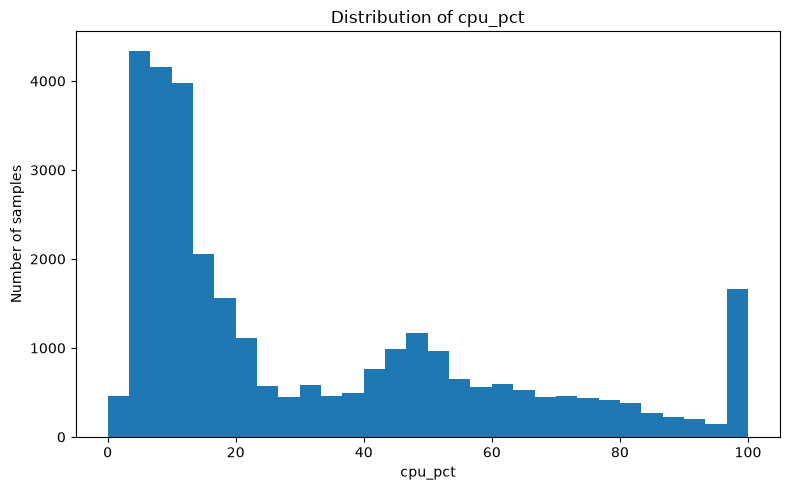

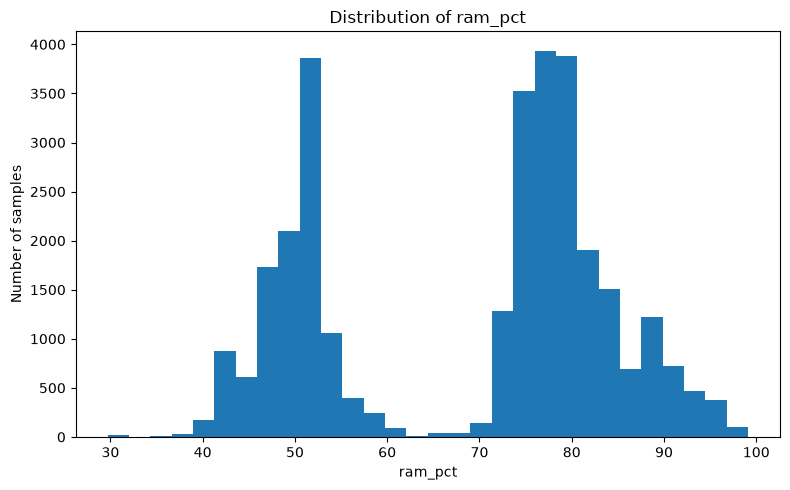

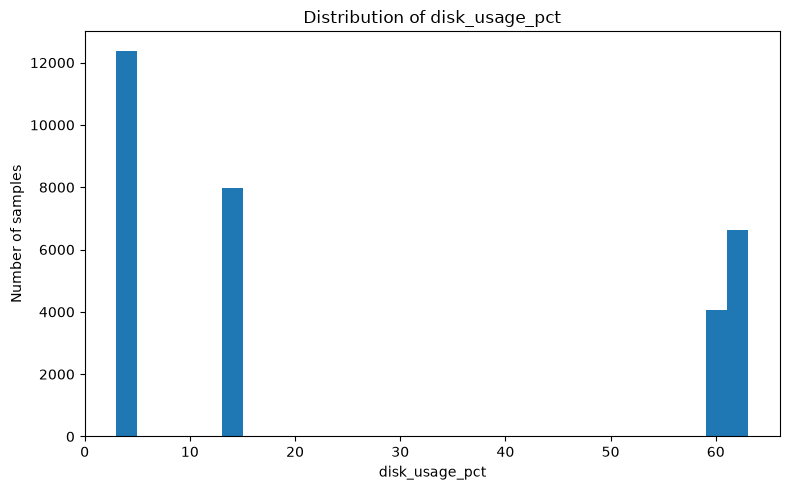

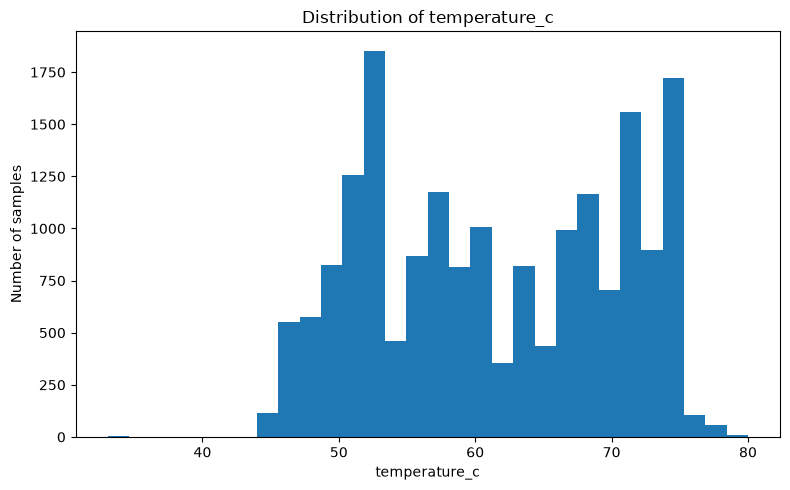

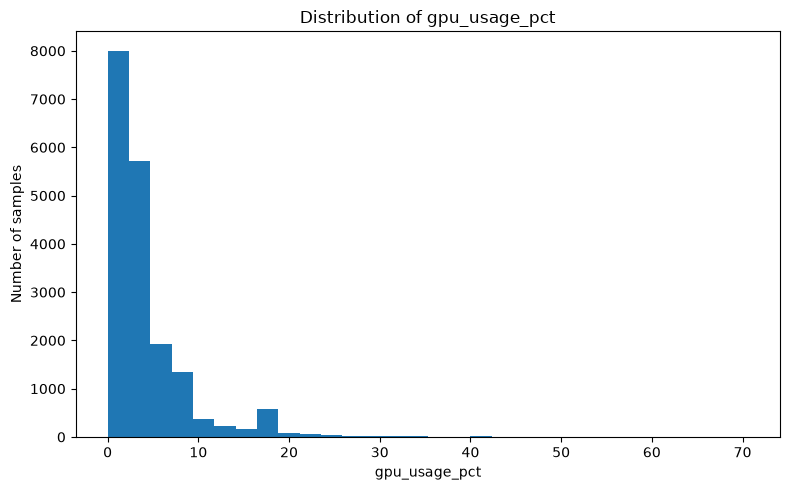

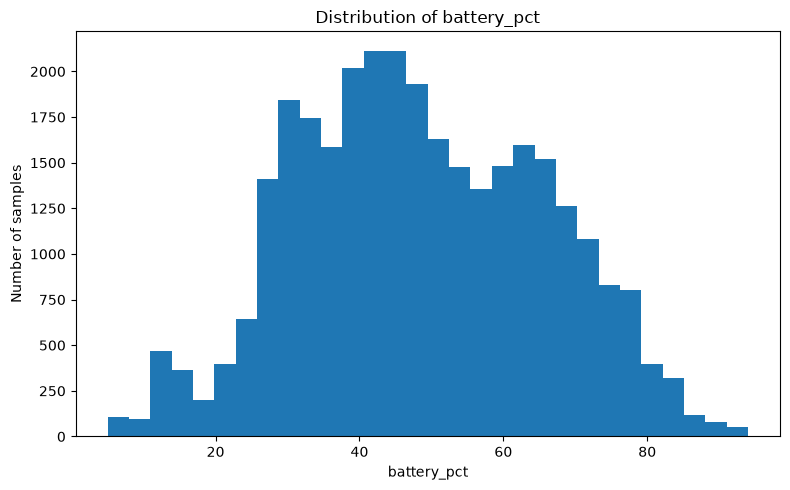

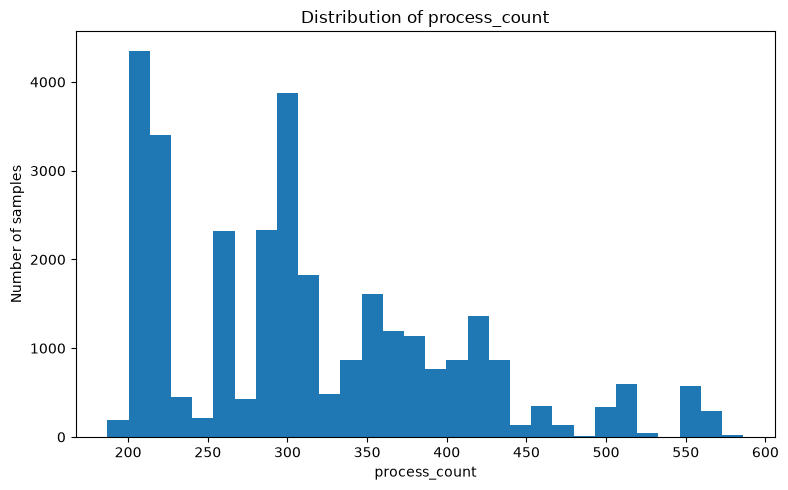

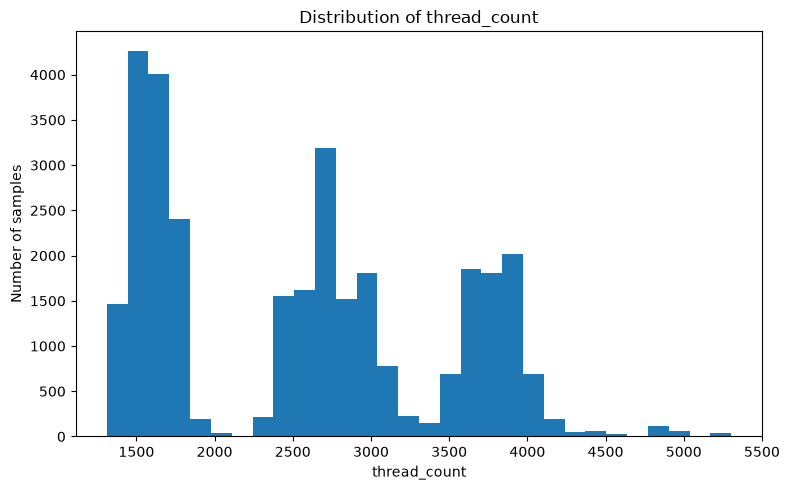

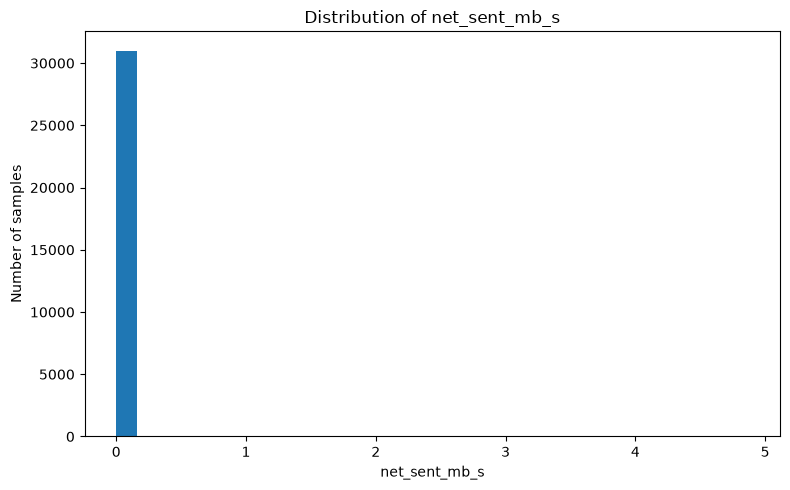

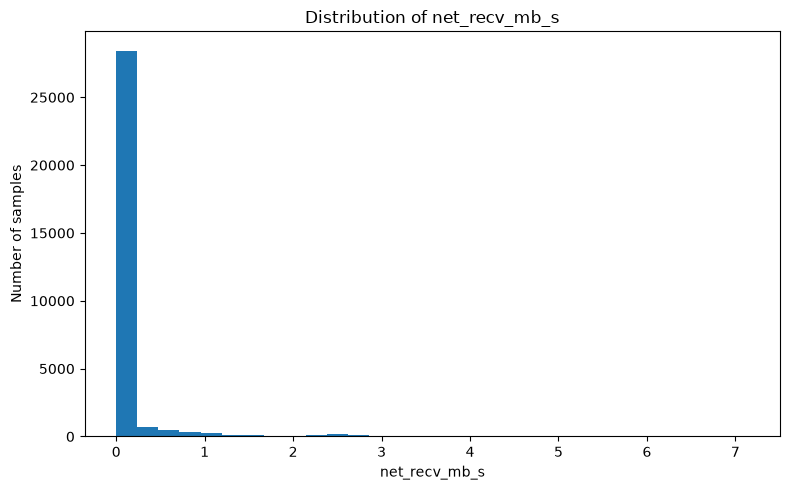

In [18]:
# Each metric gets its own histogram and output.
for column in available_important_metrics:
    plot_values = df[column].dropna()
    if plot_values.empty:
        print(column, "has no values to plot.")
        continue
    plt.figure(figsize=(8, 5))
    plt.hist(plot_values, bins=30)
    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Number of samples")
    plt.tight_layout()
    plt.show()

## 12. Outlier Analysis

Boxplots help find values far from the usual range. Missing values are removed only from each plot.

### Goal of this visualization

A boxplot summarizes the distribution of a numerical variable.

It helps identify:
- the median,
- the spread of the data,
- the typical range of values,
- and possible outliers.

Unlike a histogram, a boxplot provides a compact statistical summary.


 Minimum      Q1        Median       Q3         Maximum
    |----------|===========|===========|-------------|
    0         10          39          61          100

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


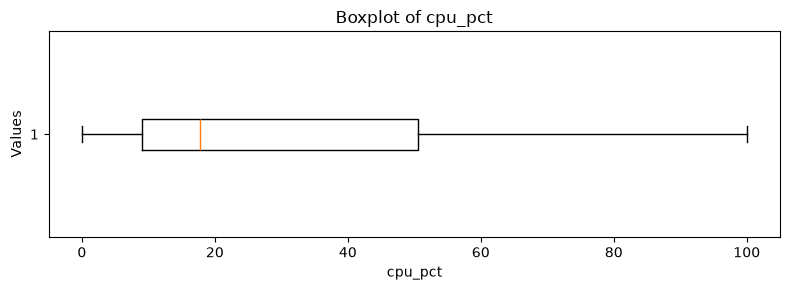

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


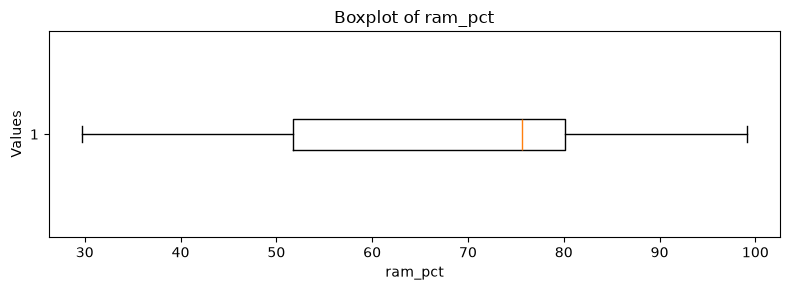

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


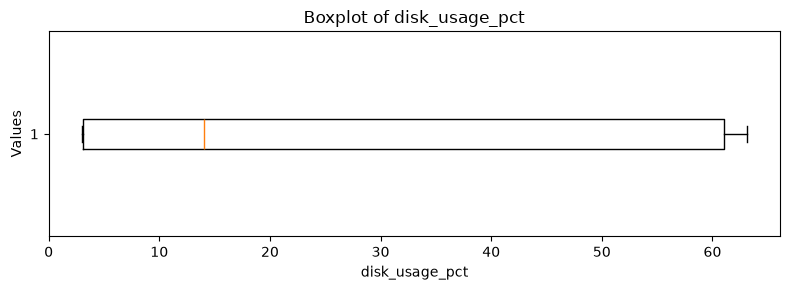

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


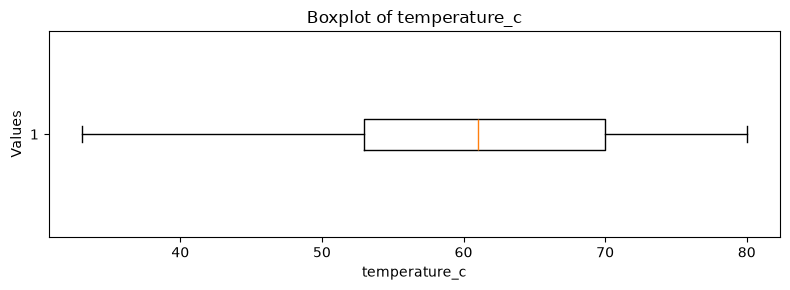

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


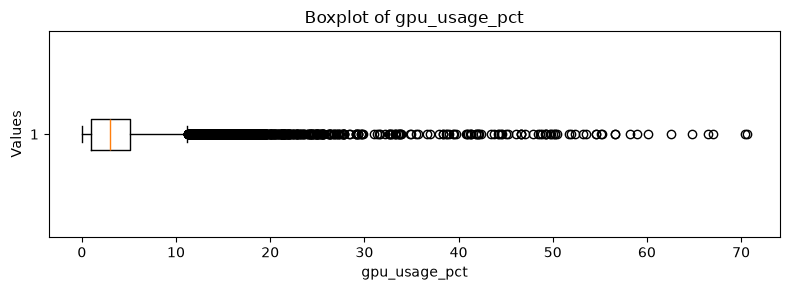

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


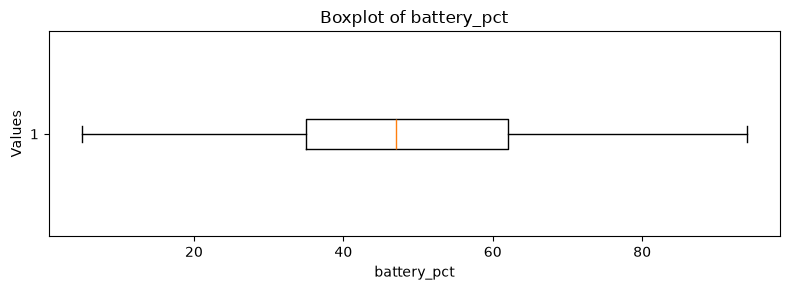

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


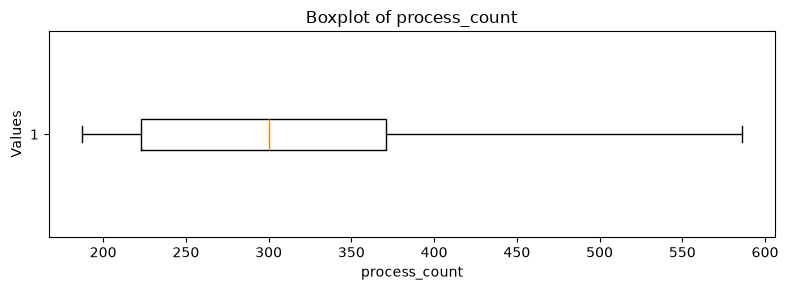

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


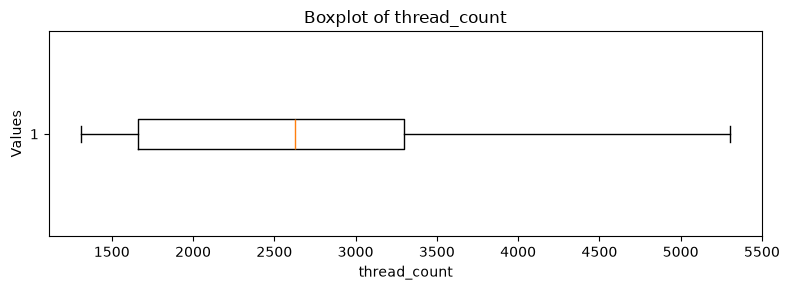

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


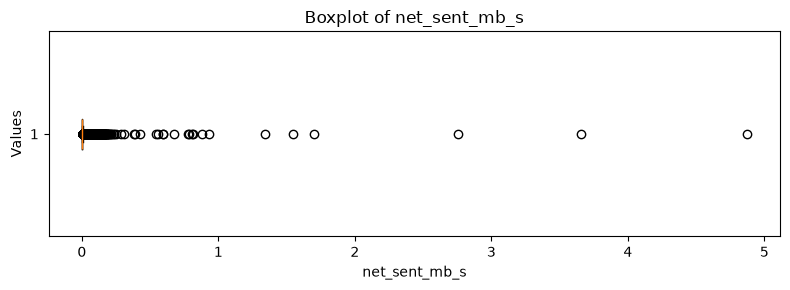

/var/folders/3h/tpfh764d3msgh0j4_bys88yr0000gn/T/ipykernel_16015/15983476.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(plot_values, vert=False)


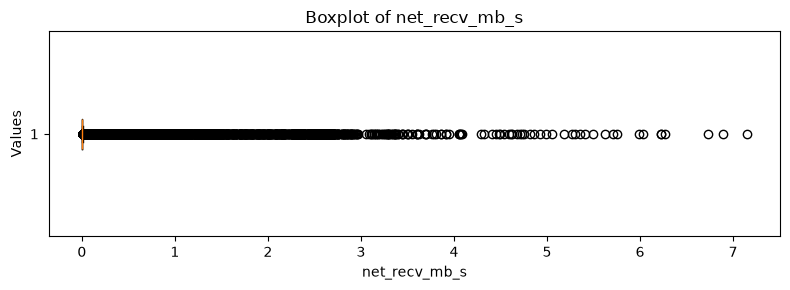

In [19]:
for column in available_important_metrics:
    plot_values = df[column].dropna()
    if plot_values.empty:
        print(column, "has no values to plot.")
        continue
    plt.figure(figsize=(8, 3))
    plt.boxplot(plot_values, vert=False)
    plt.title("Boxplot of " + column)
    plt.xlabel(column)
    plt.ylabel("Values")
    plt.tight_layout()
    plt.show()

What can you conclude from this plot?

From your boxplot, you can say:

✅ CPU usage ranges approximately from 0% to 100%.
✅ The median CPU usage is about 39%.
✅ The middle 50% of CPU measurements lie roughly between 10% and 61%.
✅ No significant outliers are visible.
✅ CPU usage shows a fairly wide spread, indicating the system experiences both low and high workloads.
🎯 One sentence to remember

A boxplot summarizes the distribution of a numerical variable by showing its minimum, first quartile (Q1), median, third quartile (Q3), maximum, and any potential outliers.


📦 Box = middle 50% of the data.
🟠 Orange line = median.
○ Circles = outliers.


### Boxplot observation

Boxplots help identify unusual observations, but they do not automatically prove that a value is incorrect. Investigate the machine, run, and collection time before deciding how to treat it.

## 13. Categorical and Quality Analysis

Study machine, run, phase, status, reliability, deadline, and battery categories.


 machine_id counts:


,count
machine_id,
0890dcc046c079acc4de4202,12386
a0f8c86097e55fbfa506d057,10694
7232bc533c21ce408d45d473,7979


,percentage
machine_id,
0890dcc046c079acc4de4202,39.88
a0f8c86097e55fbfa506d057,34.43
7232bc533c21ce408d45d473,25.69


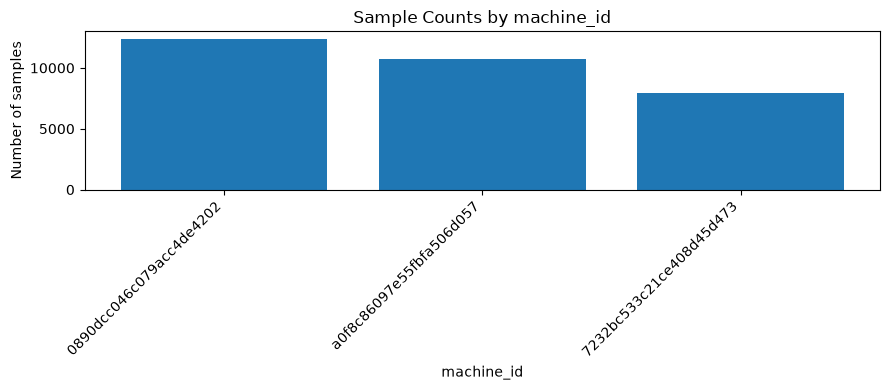


 run_id counts:


,count
run_id,
89cdc34b-e02b-43b4-9284-144276df508a,8786
70577f8e-1430-4489-8602-2096521ab84e,5895
f24e9c1a-f11e-405c-b663-45fa6e25c405,4000
6835f125-a038-4092-beff-5107ae998b39,3600
ec61755d-b5be-42ac-875d-3123e92add7a,2642
fac82c2e-545a-402a-80f8-3d1fccb72c68,2578
d88b15dd-1915-43ca-90ef-69f31ff4d9c1,2548
373070d1-ba59-4244-88ab-2d44a21f4983,422
2e9f4457-2a7f-4647-87ed-b86ac6343d33,377


,percentage
run_id,
89cdc34b-e02b-43b4-9284-144276df508a,28.29
70577f8e-1430-4489-8602-2096521ab84e,18.98
f24e9c1a-f11e-405c-b663-45fa6e25c405,12.88
6835f125-a038-4092-beff-5107ae998b39,11.59
ec61755d-b5be-42ac-875d-3123e92add7a,8.51
fac82c2e-545a-402a-80f8-3d1fccb72c68,8.30
d88b15dd-1915-43ca-90ef-69f31ff4d9c1,8.20
373070d1-ba59-4244-88ab-2d44a21f4983,1.36
2e9f4457-2a7f-4647-87ed-b86ac6343d33,1.21


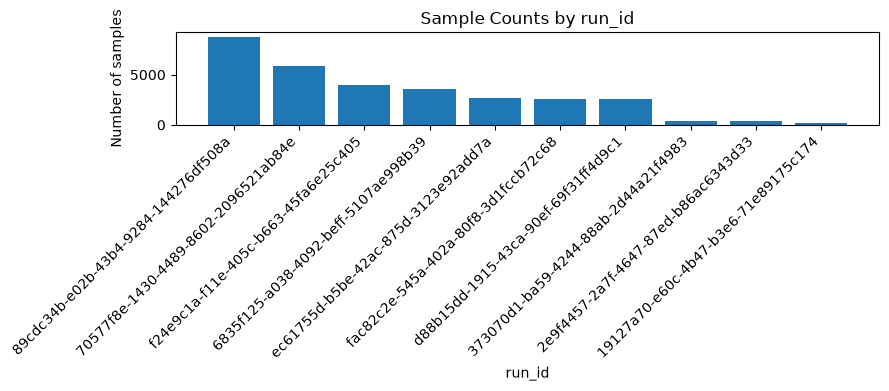


 phase counts:


,count
phase,
monitor,31059


,percentage
phase,
monitor,100.0


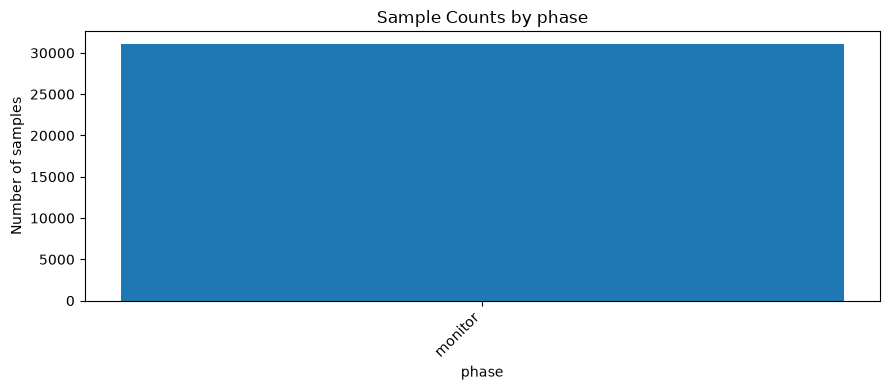


 status counts:


,count
status,
interrupted,22028
running,5431
completed,3600


,percentage
status,
interrupted,70.92
running,17.49
completed,11.59


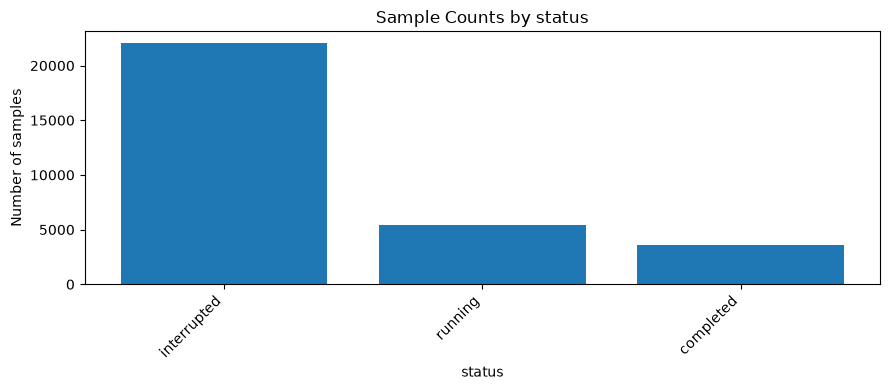


 sample_reliable counts:


,count
sample_reliable,
0,18263
1,12796


,percentage
sample_reliable,
0,58.8
1,41.2


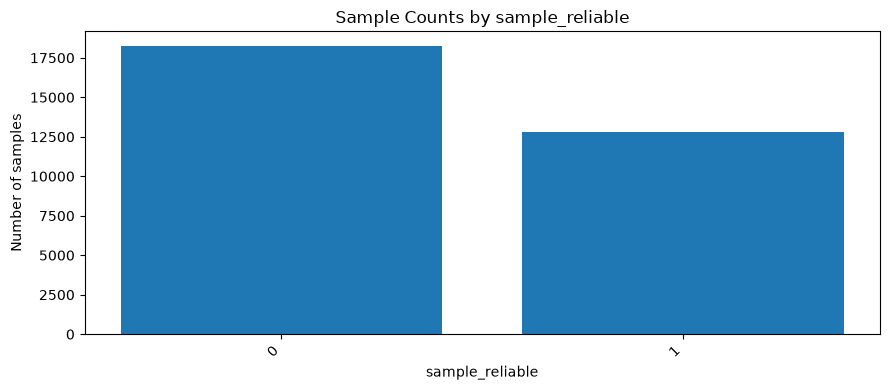


 run_complete counts:


,count
run_complete,
0,27459
1,3600


,percentage
run_complete,
0,88.41
1,11.59


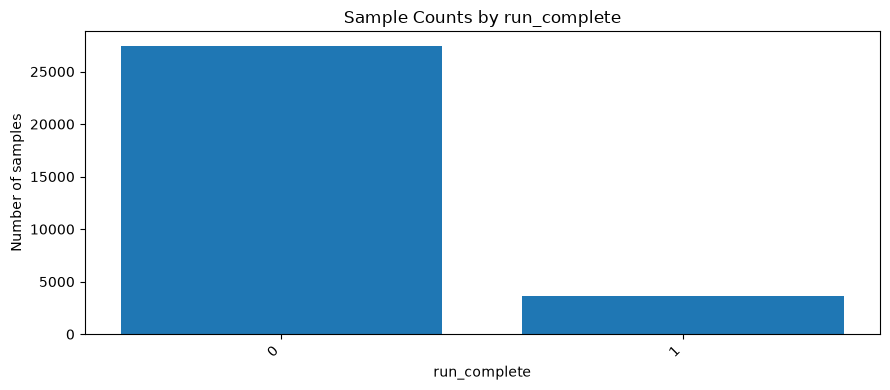


 missed_deadline counts:


,count
missed_deadline,
0,29668
1,1391


,percentage
missed_deadline,
0,95.52
1,4.48


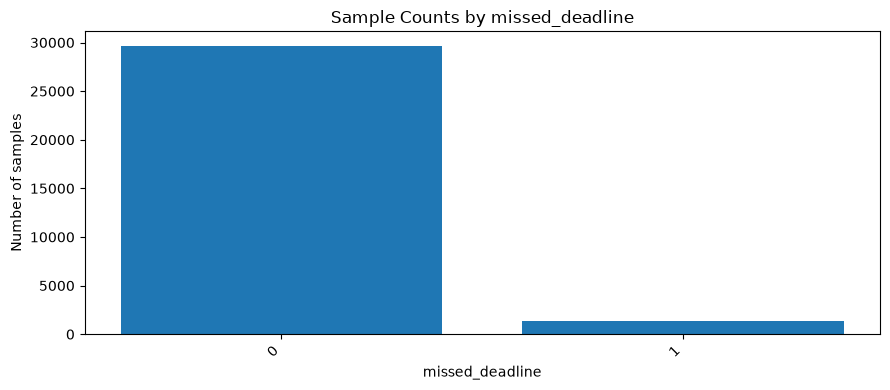


 battery_plugged counts:


,count
battery_plugged,
0,17868
1,13191


,percentage
battery_plugged,
0,57.53
1,42.47


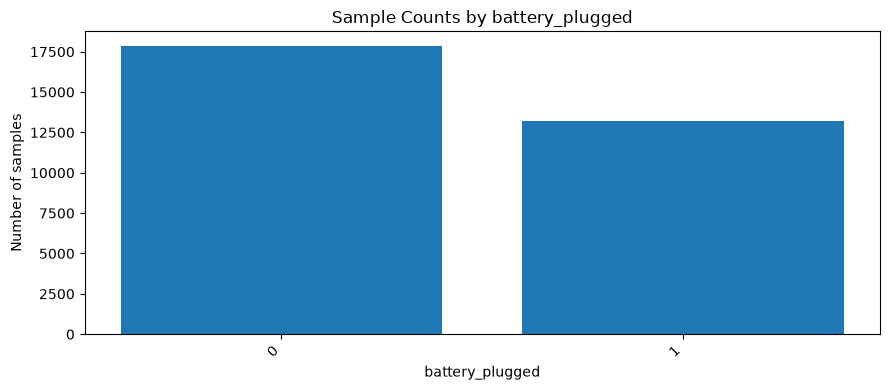

In [20]:
category_analysis = ["machine_id", "run_id", "phase", "status", "sample_reliable", "run_complete", "missed_deadline", "battery_plugged"]
for column in category_analysis:
    if column not in df.columns:
        print(column, "is not available; skipped.")
        continue
    print("\n", column, "counts:")
    display(df[column].value_counts(dropna=False).to_frame("count"))
    display((df[column].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentage"))
    if df[column].nunique(dropna=False) <= 20:
        counts = df[column].astype(str).value_counts()
        plt.figure(figsize=(9, 4))
        plt.bar(counts.index, counts.values)
        plt.title("Sample Counts by " + column)
        plt.xlabel(column)
        plt.ylabel("Number of samples")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("Chart skipped because this column has too many categories.")

### Category observation

Check whether machines and phases have balanced sample counts. Large differences may influence later comparisons.

## 14. Reliability Analysis

Measure reliable samples, complete runs, and reliability by machine.

In [26]:
if "sample_reliable" in df.columns:
    reliability_counts = df["sample_reliable"].value_counts(dropna=False)
    reliability_percentages = (df["sample_reliable"].value_counts(normalize=True, dropna=False) * 100).round(2)
    display(pd.DataFrame({"count": reliability_counts, "percentage": reliability_percentages}))
else:
    print("sample_reliable is not available.")

,count,percentage
sample_reliable,,
0,13009,60.35
1,8546,39.65


In [27]:
if "run_complete" in df.columns:
    complete_counts = df["run_complete"].value_counts(dropna=False)
    complete_percentages = (df["run_complete"].value_counts(normalize=True, dropna=False) * 100).round(2)
    display(pd.DataFrame({"count": complete_counts, "percentage": complete_percentages}))
else:
    print("run_complete is not available.")

,count,percentage
run_complete,,
0,17955,83.3
1,3600,16.7


,reliable_percentage
machine_id,
0890dcc046c079acc4de4202,0.00
0b50a7e3341e760894ab7cf3,75.05
a0f8c86097e55fbfa506d057,97.91


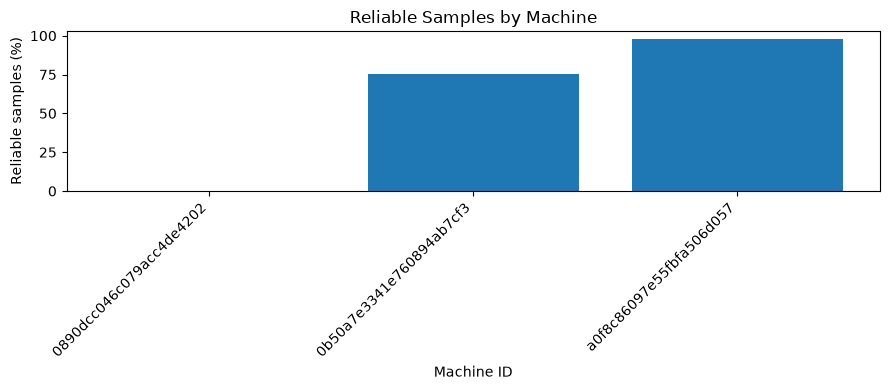

In [28]:
if {"machine_id", "sample_reliable"}.issubset(df.columns):
    reliability_by_machine = (df.groupby("machine_id")["sample_reliable"].mean() * 100).round(2)
    display(reliability_by_machine.to_frame("reliable_percentage"))
    plt.figure(figsize=(9, 4))
    plt.bar(reliability_by_machine.index.astype(str), reliability_by_machine.values)
    plt.title("Reliable Samples by Machine")
    plt.xlabel("Machine ID")
    plt.ylabel("Reliable samples (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Machine reliability comparison is unavailable.")

### Reliability observation

A low reliability percentage may mean missing sensors, missed deadlines, or other collection errors. Compare machines before choosing a preprocessing rule.

## 15. Analysis by Machine

Machines may have different hardware, so compare sample counts, runs, and average metrics carefully.

In [29]:
if "machine_id" in df.columns:
    samples_by_machine = df.groupby("machine_id").size().sort_values(ascending=False)
    display(samples_by_machine.to_frame("sample_count"))
else:
    print("machine_id is not available.")

,sample_count
machine_id,
0890dcc046c079acc4de4202,12386
a0f8c86097e55fbfa506d057,7281
0b50a7e3341e760894ab7cf3,1888


In [30]:
if {"machine_id", "run_id"}.issubset(df.columns):
    display(df.groupby("machine_id")["run_id"].nunique().to_frame("run_count"))
else:
    print("Run counts by machine are unavailable.")

,run_count
machine_id,
0890dcc046c079acc4de4202,2
0b50a7e3341e760894ab7cf3,3
a0f8c86097e55fbfa506d057,5


In [26]:
machine_average_columns = [column for column in ["cpu_pct", "ram_pct", "temperature_c"] if column in df.columns]
if "machine_id" in df.columns and machine_average_columns:
    machine_averages = df.groupby("machine_id")[machine_average_columns].mean().round(2)
    display(machine_averages)
else:
    print("Machine averages are unavailable.")

,cpu_pct,ram_pct,temperature_c
machine_id,,,
0890dcc046c079acc4de4202,9.68,77.3,NaN


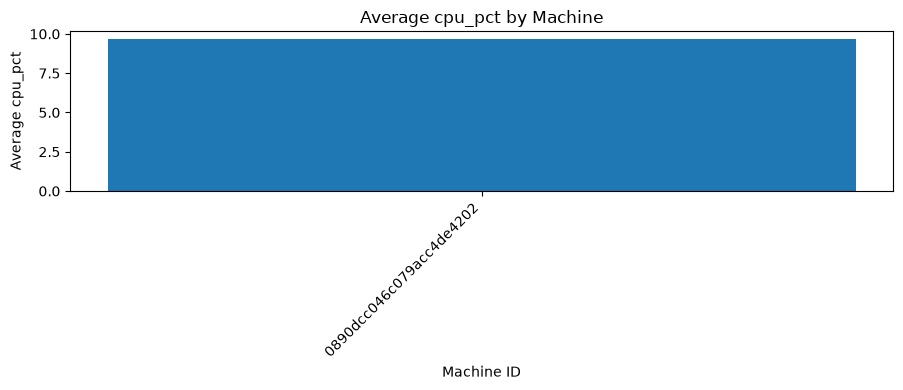

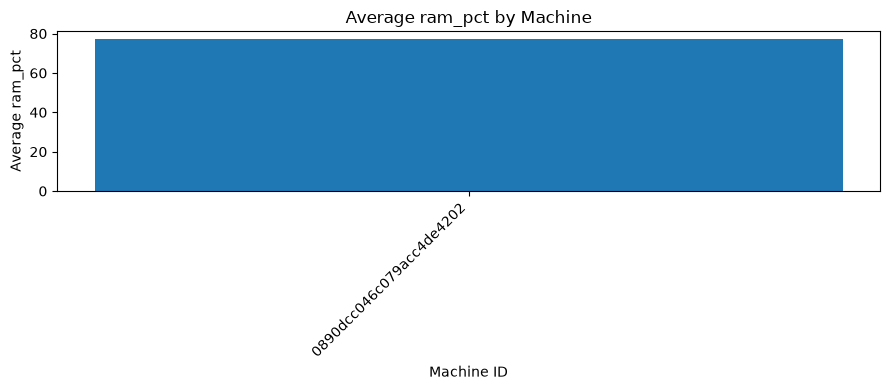

temperature_c comparison is unavailable.


In [27]:
if "machine_id" in df.columns:
    for column in ["cpu_pct", "ram_pct", "temperature_c"]:
        if column not in df.columns or df[column].dropna().empty:
            print(column, "comparison is unavailable.")
            continue
        values = df.groupby("machine_id")[column].mean().dropna()
        plt.figure(figsize=(9, 4))
        plt.bar(values.index.astype(str), values.values)
        plt.title("Average " + column + " by Machine")
        plt.xlabel("Machine ID")
        plt.ylabel("Average " + column)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

### Machine observation

Differences may be caused by workload, hardware, operating system, or collection conditions. They are not automatically data errors.

## 16. Analysis by Run

Compare run sizes, durations, and average CPU and RAM usage.

In [34]:
if "run_id" in df.columns:
    samples_by_run = df.groupby("run_id").size().sort_values(ascending=False)
    print("Ten largest runs:")
    display(samples_by_run.head(10).to_frame("sample_count"))
    print("Ten smallest runs:")
    display(samples_by_run.sort_values().head(10).to_frame("sample_count"))
else:
    print("run_id is not available.")

Ten largest runs:


,sample_count
run_id,
26a90e88-33e4-4da8-b7f5-6779af43b695,6131
9be6dd47-3f62-4ab2-9dac-cac869ed2dc0,5195
0c08eefe-d390-401a-8feb-e29800e34d10,2350
c9269d75-291c-4f94-9f8f-e4c6e973f68e,1493
59d8d4ce-b985-4efb-ac63-b66bcf5e1f83,822
600b7304-c2df-478a-8c01-8cbb02f79c38,347
cf59cb95-6087-498b-83ac-2663a9113b12,241
legacy-c09917a5fc90e296,158
cac214d1-16a2-41d0-9b80-7ac51fc81228,145


Ten smallest runs:


,sample_count
run_id,
legacy-cf8963566dd3b3b2,5
2604405b-7663-4d80-928d-4def676c1e74,20
506256a3-eed9-423e-b209-4a88cc892e42,48
cac214d1-16a2-41d0-9b80-7ac51fc81228,145
legacy-c09917a5fc90e296,158
cf59cb95-6087-498b-83ac-2663a9113b12,241
600b7304-c2df-478a-8c01-8cbb02f79c38,347
59d8d4ce-b985-4efb-ac63-b66bcf5e1f83,822
c9269d75-291c-4f94-9f8f-e4c6e973f68e,1493


In [35]:
if {"run_id", "timestamp"}.issubset(df.columns):
    run_times = df.groupby("run_id")["timestamp"].agg(["min", "max"])
    run_times["duration_minutes"] = (run_times["max"] - run_times["min"]).dt.total_seconds() / 60
    print("Shortest runs:")
    display(run_times.sort_values("duration_minutes").head(10))
    print("Longest runs:")
    display(run_times.sort_values("duration_minutes", ascending=False).head(10))
else:
    print("Run duration analysis is unavailable.")

Shortest runs:


,min,max,duration_minutes
run_id,,,
2604405b-7663-4d80-928d-4def676c1e74,2026-07-19 20:25:13.800000+00:00,2026-07-19 20:25:50.145000+00:00,0.605750
506256a3-eed9-423e-b209-4a88cc892e42,2026-07-18 14:59:50.625000+00:00,2026-07-18 15:02:07.894000+00:00,2.287817
cac214d1-16a2-41d0-9b80-7ac51fc81228,2026-07-20 00:45:56.766000+00:00,2026-07-20 00:50:45.492000+00:00,4.812100
cf59cb95-6087-498b-83ac-2663a9113b12,2026-07-18 22:11:05.811000+00:00,2026-07-18 22:19:05.279000+00:00,7.991133
legacy-cf8963566dd3b3b2,2026-07-15 22:10:07+00:00,2026-07-15 22:29:29+00:00,19.366667
legacy-c09917a5fc90e296,2026-07-17 16:09:40+00:00,2026-07-17 16:35:51+00:00,26.183333
59d8d4ce-b985-4efb-ac63-b66bcf5e1f83,2026-07-19 23:42:29.605000+00:00,2026-07-20 00:30:13.689000+00:00,47.734733
c9269d75-291c-4f94-9f8f-e4c6e973f68e,2026-07-18 16:01:56.800000+00:00,2026-07-18 16:51:39.431000+00:00,49.710517
0c08eefe-d390-401a-8feb-e29800e34d10,2026-07-20 18:22:59.178000+00:00,2026-07-20 19:42:48.845000+00:00,79.827783


Longest runs:


,min,max,duration_minutes
run_id,,,
26a90e88-33e4-4da8-b7f5-6779af43b695,2026-07-20 16:04:41.924000+00:00,2026-07-20 19:29:01.889000+00:00,204.332750
600b7304-c2df-478a-8c01-8cbb02f79c38,2026-07-17 20:31:35.812000+00:00,2026-07-17 23:49:40.089000+00:00,198.071283
9be6dd47-3f62-4ab2-9dac-cac869ed2dc0,2026-07-20 15:14:05.964000+00:00,2026-07-20 18:09:09.710000+00:00,175.062433
0c08eefe-d390-401a-8feb-e29800e34d10,2026-07-20 18:22:59.178000+00:00,2026-07-20 19:42:48.845000+00:00,79.827783
c9269d75-291c-4f94-9f8f-e4c6e973f68e,2026-07-18 16:01:56.800000+00:00,2026-07-18 16:51:39.431000+00:00,49.710517
59d8d4ce-b985-4efb-ac63-b66bcf5e1f83,2026-07-19 23:42:29.605000+00:00,2026-07-20 00:30:13.689000+00:00,47.734733
legacy-c09917a5fc90e296,2026-07-17 16:09:40+00:00,2026-07-17 16:35:51+00:00,26.183333
legacy-cf8963566dd3b3b2,2026-07-15 22:10:07+00:00,2026-07-15 22:29:29+00:00,19.366667
cf59cb95-6087-498b-83ac-2663a9113b12,2026-07-18 22:11:05.811000+00:00,2026-07-18 22:19:05.279000+00:00,7.991133


In [36]:
run_metric_columns = [column for column in ["cpu_pct", "ram_pct"] if column in df.columns]
if "run_id" in df.columns and run_metric_columns:
    run_averages = df.groupby("run_id")[run_metric_columns].mean().round(2)
    display(run_averages.head(10))
else:
    print("Run averages are unavailable.")

,cpu_pct,ram_pct
run_id,,
0c08eefe-d390-401a-8feb-e29800e34d10,57.16,69.74
2604405b-7663-4d80-928d-4def676c1e74,35.11,73.15
26a90e88-33e4-4da8-b7f5-6779af43b695,8.34,66.31
506256a3-eed9-423e-b209-4a88cc892e42,54.58,89.69
59d8d4ce-b985-4efb-ac63-b66bcf5e1f83,63.35,80.82
600b7304-c2df-478a-8c01-8cbb02f79c38,70.90,89.78
9be6dd47-3f62-4ab2-9dac-cac869ed2dc0,61.44,85.67
c9269d75-291c-4f94-9f8f-e4c6e973f68e,18.78,78.81
cac214d1-16a2-41d0-9b80-7ac51fc81228,71.96,85.43


### Run observation

Very short or long runs should be reviewed. Run duration can affect how representative its averages are.

## 17. Correlation Analysis

Correlation measures how two numerical variables move together. It does not prove that one variable causes another.

In [28]:
identifier_like_columns = ["id", "legacy_id"]
correlation_columns = [column for column in numeric_columns if column not in identifier_like_columns]
if correlation_columns:
    correlation_matrix = df[correlation_columns].corr()
    display(correlation_matrix.round(2))
else:
    correlation_matrix = pd.DataFrame()
    print("No numerical columns are available for correlation.")

,elapsed_seconds,stress_cpu_target_pct,stress_memory_target_mb,cpu_pct,cpu_frequency_mhz,ram_pct,ram_used_mb,ram_available_mb,swap_pct,swap_used_mb,...,process_count,thread_count,context_switches_per_s,temperature_c,gpu_usage_pct,battery_pct,battery_plugged,missed_deadline,sample_reliable,run_complete
elapsed_seconds,1.00,NaN,NaN,-0.04,NaN,0.19,-0.24,-0.19,-0.44,-0.46,...,-0.16,0.10,-0.05,NaN,NaN,-0.32,0.62,NaN,NaN,-0.47
stress_cpu_target_pct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stress_memory_target_mb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu_pct,-0.04,NaN,NaN,1.00,NaN,0.17,-0.02,-0.17,0.08,0.07,...,0.03,0.15,0.14,NaN,NaN,0.09,0.14,NaN,NaN,0.05
cpu_frequency_mhz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ram_pct,0.19,NaN,NaN,0.17,NaN,1.00,-0.94,-1.00,0.64,0.66,...,-0.67,-0.49,-0.03,NaN,NaN,-0.48,0.31,NaN,NaN,0.66
ram_used_mb,-0.24,NaN,NaN,-0.02,NaN,-0.94,1.00,0.94,-0.63,-0.65,...,0.71,0.58,0.04,NaN,NaN,0.57,-0.24,NaN,NaN,-0.65
ram_available_mb,-0.19,NaN,NaN,-0.17,NaN,-1.00,0.94,1.00,-0.65,-0.66,...,0.67,0.49,0.03,NaN,NaN,0.48,-0.31,NaN,NaN,-0.66
swap_pct,-0.44,NaN,NaN,0.08,NaN,0.64,-0.63,-0.65,1.00,0.99,...,-0.53,-0.62,-0.02,NaN,NaN,-0.29,-0.14,NaN,NaN,0.95
swap_used_mb,-0.46,NaN,NaN,0.07,NaN,0.66,-0.65,-0.66,0.99,1.00,...,-0.58,-0.70,-0.03,NaN,NaN,-0.37,-0.19,NaN,NaN,0.99


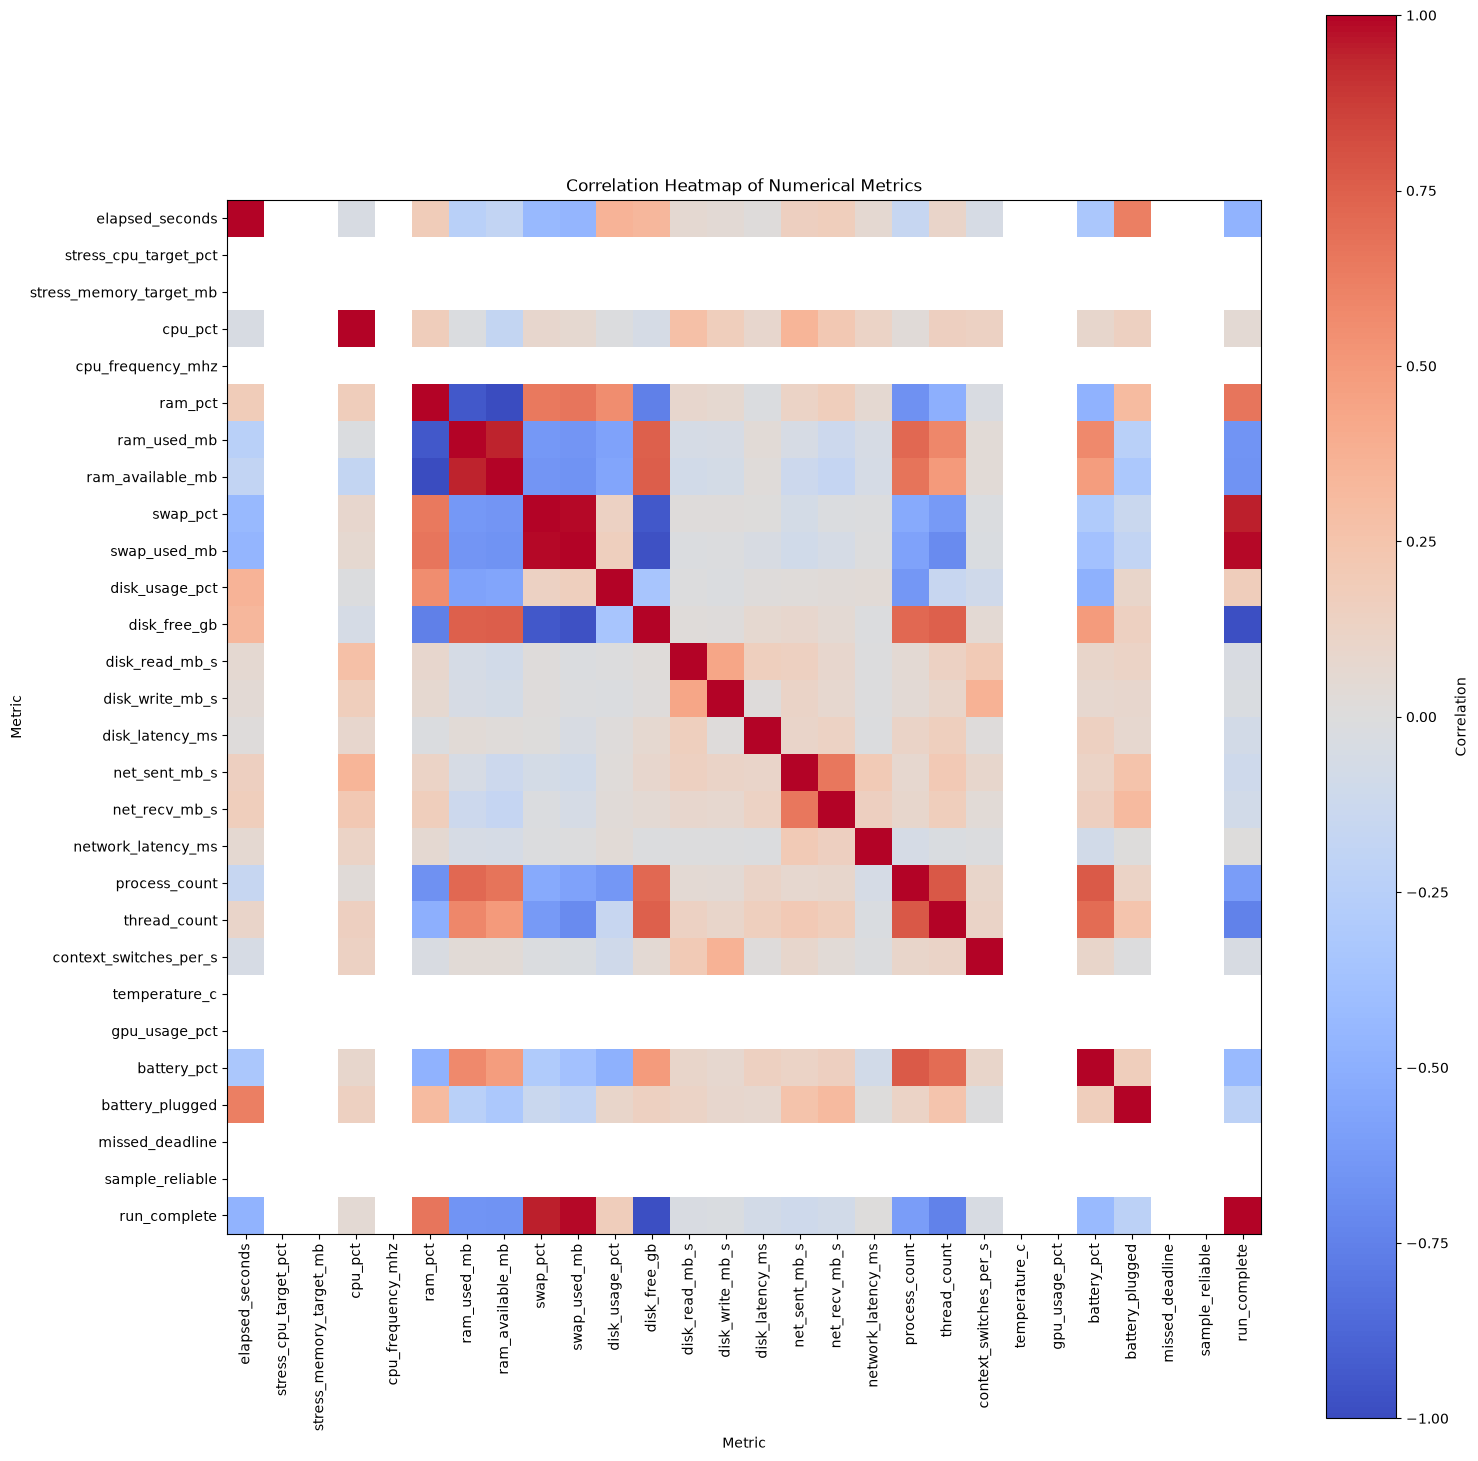

In [29]:
if not correlation_matrix.empty:
    size = max(8, len(correlation_matrix) * 0.55)
    plt.figure(figsize=(size, size))
    image = plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(image, label="Correlation")
    plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
    plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
    plt.title("Correlation Heatmap of Numerical Metrics")
    plt.xlabel("Metric")
    plt.ylabel("Metric")
    plt.tight_layout()
    plt.show()
else:
    print("Correlation heatmap skipped.")

In [30]:
if not correlation_matrix.empty:
    correlation_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)).stack()
    strongest_positive = correlation_pairs.sort_values(ascending=False).head(10)
    strongest_negative = correlation_pairs.sort_values().head(10)
    print("Strongest positive correlations:")
    display(strongest_positive.to_frame("correlation"))
    print("Strongest negative correlations:")
    display(strongest_negative.to_frame("correlation"))
else:
    print("Strongest correlation tables are unavailable.")

Strongest positive correlations:


correlation
swap_used_mb     run_complete         0.989621
swap_pct         swap_used_mb         0.985449
                 run_complete         0.951076
ram_used_mb      ram_available_mb     0.943491
process_count    thread_count         0.779630
                 battery_pct          0.766452
ram_available_mb disk_free_gb         0.752994
ram_used_mb      disk_free_gb         0.749408
disk_free_gb     thread_count         0.744321
                 process_count        0.716872

Strongest negative correlations:


,,correlation
ram_pct,ram_available_mb,-0.999936
disk_free_gb,run_complete,-0.979688
swap_used_mb,disk_free_gb,-0.974440
ram_pct,ram_used_mb,-0.943426
swap_pct,disk_free_gb,-0.942797
ram_pct,disk_free_gb,-0.752834
thread_count,run_complete,-0.744815
swap_used_mb,thread_count,-0.695718
ram_pct,process_count,-0.665278
ram_available_mb,swap_used_mb,-0.658393


### Correlation observation

Focus on strong positive and negative relationships. Remember that correlation does not show causation.

## 18. Time-Based Analysis

Use a temporary sorted copy so the original dataframe order is not changed. Minute averages keep long series readable.

In [31]:
if "timestamp" in df.columns and df["timestamp"].notna().any():
    time_df = df.dropna(subset=["timestamp"]).sort_values("timestamp").copy()
    print("First timestamp:", time_df["timestamp"].min())
    print("Last timestamp:", time_df["timestamp"].max())
    print("Total collection period:", time_df["timestamp"].max() - time_df["timestamp"].min())
    samples_per_minute = time_df.set_index("timestamp").resample("1min").size()
    display(samples_per_minute.head().to_frame("sample_count"))
else:
    time_df = pd.DataFrame()
    print("Valid timestamps are unavailable.")

First timestamp: 2026-07-23 15:00:46.964000+00:00
Last timestamp: 2026-07-25 16:45:56.941000+00:00
Total collection period: 2 days 01:45:09.977000


,sample_count
timestamp,
2026-07-23 15:00:00+00:00,7
2026-07-23 15:01:00+00:00,30
2026-07-23 15:02:00+00:00,30
2026-07-23 15:03:00+00:00,30
2026-07-23 15:04:00+00:00,30


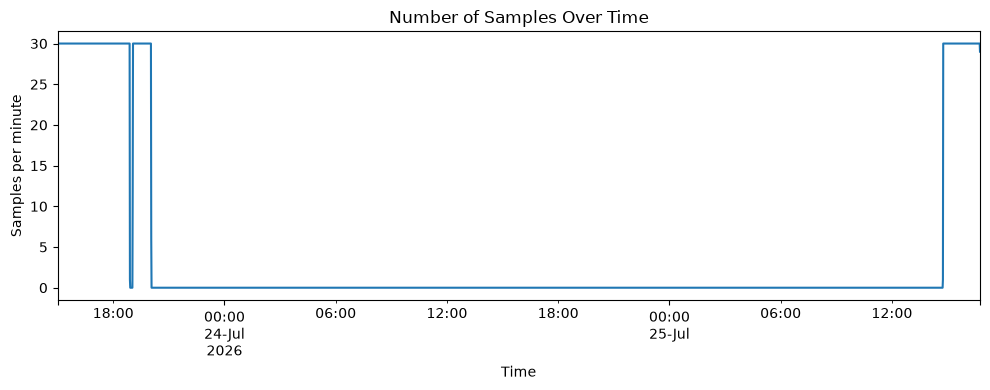

In [32]:
if not time_df.empty:
    samples_per_minute.plot(figsize=(10, 4))
    plt.title("Number of Samples Over Time")
    plt.xlabel("Time")
    plt.ylabel("Samples per minute")
    plt.tight_layout()
    plt.show()

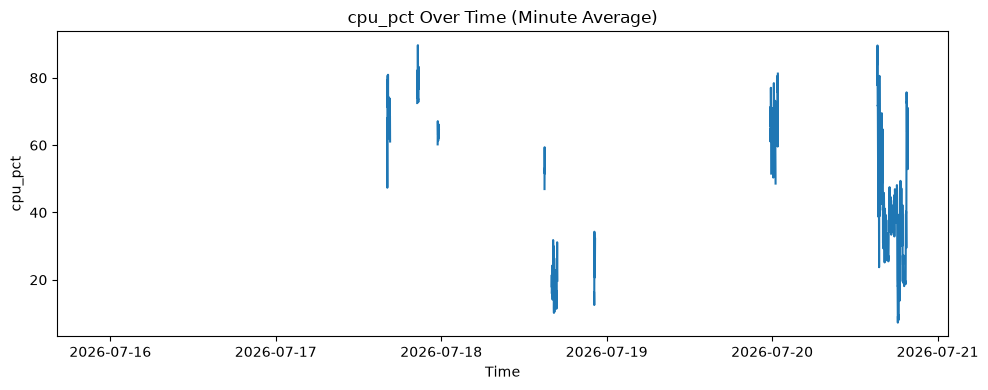

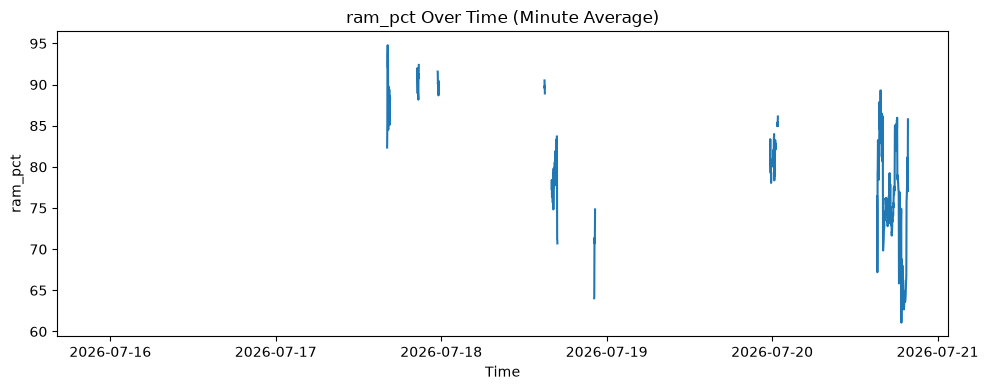

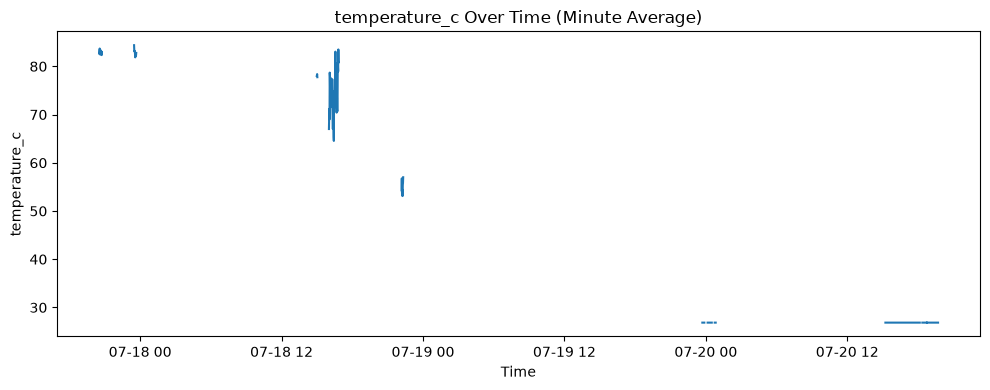

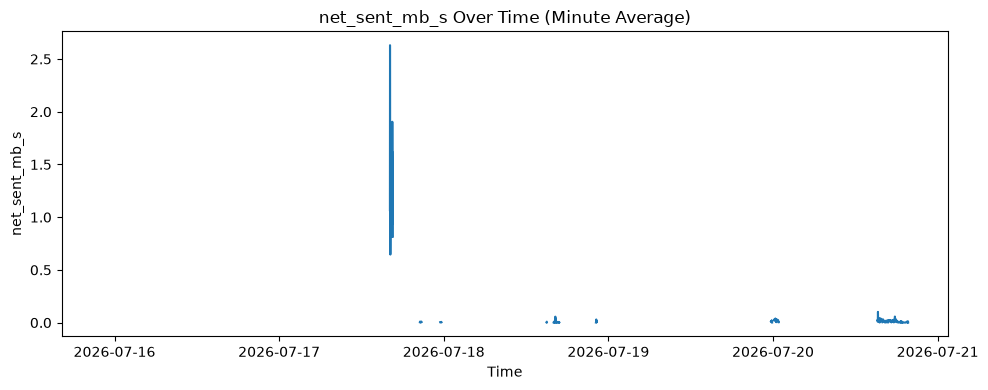

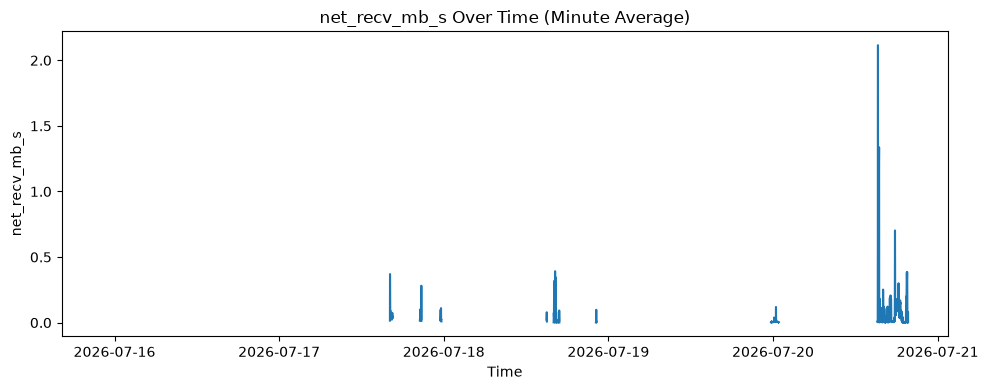

In [42]:
if not time_df.empty:
    for column in ["cpu_pct", "ram_pct", "temperature_c", "net_sent_mb_s", "net_recv_mb_s"]:
        if column not in time_df.columns or time_df[column].dropna().empty:
            print(column, "time chart is unavailable.")
            continue
        minute_values = time_df.set_index("timestamp")[column].resample("1min").mean()
        plt.figure(figsize=(10, 4))
        plt.plot(minute_values.index, minute_values.values)
        plt.title(column + " Over Time (Minute Average)")
        plt.xlabel("Time")
        plt.ylabel(column)
        plt.tight_layout()
        plt.show()

### Time observation

Look for peaks, drops, long trends, and gaps. Compare them with run phases and machines before making a preprocessing decision.

## 19. Sensor-Error Analysis

Check whether sensor error text is empty and compare it with reliability.

In [33]:
if "sensor_errors_json" in df.columns:
    error_text = df["sensor_errors_json"].fillna("").astype(str).str.strip()
    has_sensor_error = ~error_text.isin(["", "{}", "null", "None", "nan"])
    print("Rows without sensor errors:", (~has_sensor_error).sum())
    print("Rows with sensor errors:", has_sensor_error.sum())
    print("Examples of sensor errors:")
    display(df.loc[has_sensor_error, "sensor_errors_json"].drop_duplicates().head(10))
else:
    has_sensor_error = pd.Series(False, index=df.index)
    print("sensor_errors_json is not available.")

Rows without sensor errors: 0
Rows with sensor errors: 12386
Examples of sensor errors:


0    {"network_latency": "TimeoutError: timed out",...
1    {"temperature": "macmon_not_installed (install...
Name: sensor_errors_json, dtype: str

In [34]:
if "sensor_errors_json" in df.columns and "sample_reliable" in df.columns:
    reliability_and_errors = pd.crosstab(has_sensor_error, df["sample_reliable"], margins=True)
    reliability_and_errors.index.name = "has_sensor_error"
    display(reliability_and_errors)
else:
    print("Sensor-error and reliability comparison is unavailable.")

sample_reliable,0,All
has_sensor_error,,
True,12386,12386
All,12386,12386


### Sensor-error observation

Frequent errors for one sensor or machine may explain missing values and lower reliability.

## 20. Important Validation Checks

These checks find suspicious values. They do not prove that the values are errors, and no rows are deleted.

In [35]:
range_columns = ["cpu_pct", "ram_pct", "disk_usage_pct", "battery_pct"]
for column in range_columns:
    if column in df.columns:
        suspicious = df[(df[column] < 0) | (df[column] > 100)]
        print(column, "outside 0 to 100:", len(suspicious))
        if not suspicious.empty:
            display(suspicious[[column]].head(10))
    else:
        print(column, "is not available; skipped.")

cpu_pct outside 0 to 100: 0
ram_pct outside 0 to 100: 0
disk_usage_pct outside 0 to 100: 0
battery_pct outside 0 to 100: 0


In [36]:
non_negative_columns = [
    "net_sent_mb_s", "net_recv_mb_s", "disk_read_mb_s", "disk_write_mb_s",
    "process_count", "thread_count"
]
for column in non_negative_columns:
    if column in df.columns:
        suspicious = df[df[column] < 0]
        print(column, "negative values:", len(suspicious))
        if not suspicious.empty:
            display(suspicious[[column]].head(10))
    else:
        print(column, "is not available; skipped.")

net_sent_mb_s negative values: 0
net_recv_mb_s negative values: 0
disk_read_mb_s negative values: 0
disk_write_mb_s negative values: 0
process_count negative values: 0
thread_count negative values: 0


### Validation observation

Investigate suspicious rows using machine, run, timestamp, and phase. Some unusual values may still be valid.

## Key Findings and Observations

Complete this template after running and interpreting the notebook:

- **Dataset size:**
- **Number of machines:**
- **Number of runs:**
- **Collection period:**
- **Main missing-value problems:**
- **Percentage of reliable samples:**
- **Percentage of complete runs:**
- **Main numerical distributions:**
- **Main outliers:**
- **Strongest correlations:**
- **Differences between machines:**
- **Important time-based patterns:**
- **Suspicious or invalid values:**
- **Decisions required for preprocessing:**

## Final Conclusion

EDA helped us understand the structure and quality of the system metrics. No preprocessing decision should be made before interpreting the results.

The next step is preprocessing, including missing-value treatment, feature selection, encoding, scaling, and possible outlier treatment.

The original cleaned dataset was not modified.